In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="LxSDqMlGhP5jKsgsCom8")
project = rf.workspace("khaleds-workspace-swezy").project("spot-classification")
version = project.version(1)
dataset = version.download("folder")


loading Roboflow workspace...
loading Roboflow project...


In [2]:
!pip install torchinfo

In [3]:
import os
from pathlib import Path
import random
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
def walk_throught(dataset_path):
  for dir_path, dir_name, file_name in os.walk(dataset_path):
    print(f'Threr are {len(dir_name)} dirs and {len(file_name)} files in {dir_path} ')
walk_throught('/content/spot-classification-1')

Threr are 2 dirs and 2 files in /content/spot-classification-1 
Threr are 2 dirs and 0 files in /content/spot-classification-1/train 
Threr are 0 dirs and 256 files in /content/spot-classification-1/train/FreeSpots 
Threr are 0 dirs and 596 files in /content/spot-classification-1/train/BusySpots 
Threr are 2 dirs and 0 files in /content/spot-classification-1/valid 
Threr are 0 dirs and 17 files in /content/spot-classification-1/valid/FreeSpots 
Threr are 0 dirs and 28 files in /content/spot-classification-1/valid/BusySpots 


5


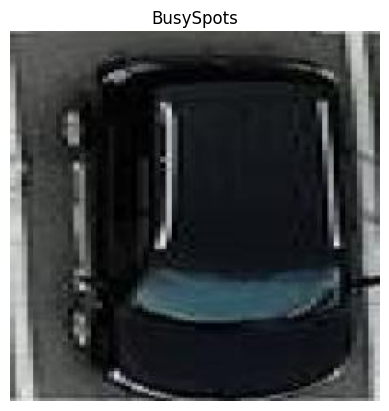

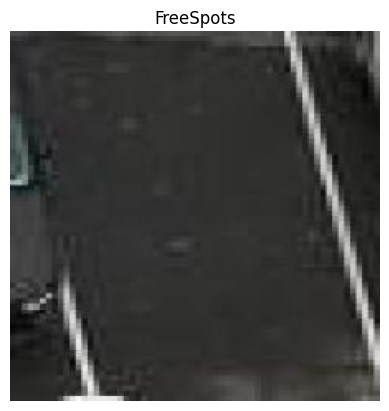

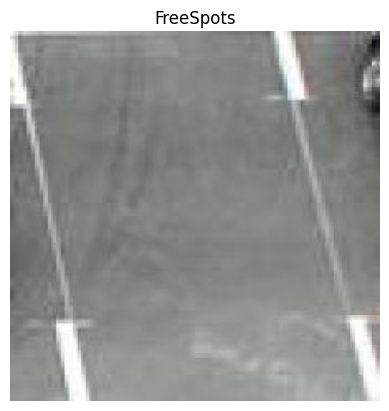

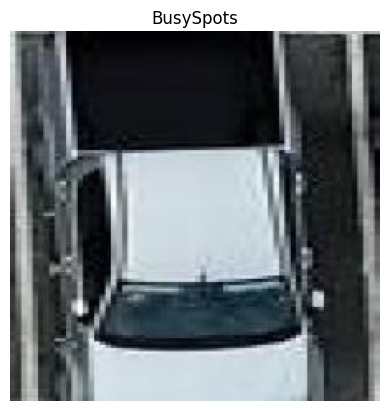

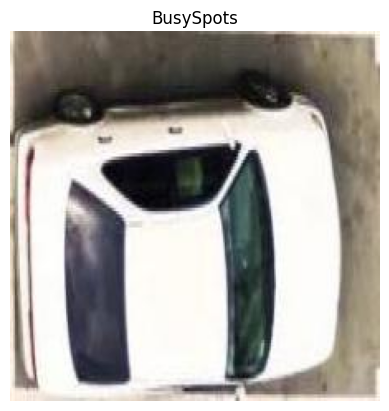

In [5]:
def random_samples(images_path: Path, n= 5, seed= True):
  if n > 5:
    raise ValueError("n must be less than or equal 5")
  if seed:
    random.seed(42)
  imgs_list = list(images_path.glob('*/*.jpg'))
  samples = random.sample(imgs_list, k= n)
  for i in range(n):
    img = Image.open(samples[i])
    plt.figure()
    plt.imshow(img)
    plt.axis(False)
    plt.title(f'{samples[i].parent.stem}')
  print(len(samples))
random_samples(Path("/content/spot-classification-1/train" ))

In [6]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torchinfo import summary

In [7]:
base_dir = Path("/content/spot-classification-1")
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'valid')

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(31),
    # transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    # transforms.RandomRotation(degrees=10),
    # transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.225, 0.224]
    )
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.225, 0.224]
    )
])

In [9]:
train_dataset = datasets.ImageFolder(
    root = train_dir,
    transform= train_transform,
    target_transform= None
)
test_dataset = datasets.ImageFolder(
    root = test_dir,
    transform= test_transform,
    target_transform= None
)

In [10]:
train_dataset.classes

['BusySpots', 'FreeSpots']

In [11]:
idx = train_dataset.class_to_idx
idx

{'BusySpots': 0, 'FreeSpots': 1}

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

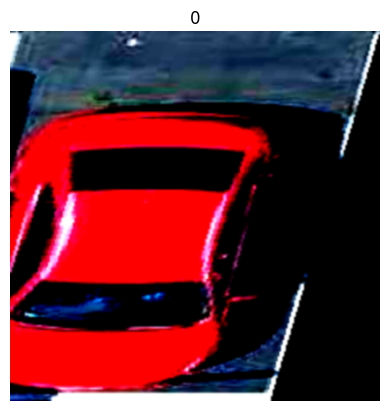

In [12]:
img, label = train_dataset[4]
plt.imshow(img.permute(1, 2, 0), interpolation= 'BICUBIC')
plt.title(label)
plt.axis(False)

In [13]:
print(len(train_dataset))

852


In [14]:
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
)

In [15]:
print(len(train_loader))

27


Initialize Model

In [16]:
def initialize_model():
  weights = torchvision.models.EfficientNet_B0_Weights
  model = torchvision.models.efficientnet_b0(weights=weights)
  return model

In [17]:
effnet_model = initialize_model()
summary(effnet_model)

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.


Layer (type:depth-idx)                                  Param #
EfficientNet                                            --
├─Sequential: 1-1                                       --
│    └─Conv2dNormActivation: 2-1                        --
│    │    └─Conv2d: 3-1                                 864
│    │    └─BatchNorm2d: 3-2                            64
│    │    └─SiLU: 3-3                                   --
│    └─Sequential: 2-2                                  --
│    │    └─MBConv: 3-4                                 1,448
│    └─Sequential: 2-3                                  --
│    │    └─MBConv: 3-5                                 6,004
│    │    └─MBConv: 3-6                                 10,710
│    └─Sequential: 2-4                                  --
│    │    └─MBConv: 3-7                                 15,350
│    │    └─MBConv: 3-8                                 31,290
│    └─Sequential: 2-5                                  --
│    │    └─MBConv: 3-9         

In [18]:
effnet_model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [19]:
def freeze_all_except_classification(model, num_classes= 2):
  for param in model.parameters():
    param.requires_grad = False
  model.classifier = nn.Sequential(
      nn.Dropout(p=0.2, inplace=True),
      nn.Linear(in_features=1280, out_features=2, bias=True)
  )
  return model

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
effnet_model = freeze_all_except_classification(effnet_model, 2).to(device)

In [21]:
device = next(effnet_model.parameters()).device
device

device(type='cuda', index=0)

In [22]:
# free_weight = 852/(2*256)
# busy_weight = 852/(2*(852-256))

In [23]:
torch.manual_seed(42)
optimizer = torch.optim.AdamW(
    effnet_model.classifier.parameters(),
    lr = 1e-4
)
loss_fn = nn.CrossEntropyLoss(weight = torch.tensor([1.0, 2.9]).to(device))
def accuracy_fn(y_true, y_pred):
  y_true = y_true.cpu().numpy()
  y_pred = y_pred.cpu().numpy()
  return np.sum(y_pred== y_true) / len(y_true)

In [24]:
def train_step(model: nn.Module,
               train_loader: torch.utils.data.DataLoader,
               optimizer:torch.optim.AdamW,
               loss_fn: nn.CrossEntropyLoss,
               device= device):
  train_acc, train_loss = 0, 0
  progress_bar = tqdm(train_loader, desc= 'Training', leave= False)
  model.train()
  for batch_num , (X, y) in enumerate(progress_bar):
    X, y = X.to(device), y.to(device)
    y_logits = model(X)
    # loss and accuracy
    loss = loss_fn(y_logits, y)
    y_norm = torch.softmax(y_logits, dim =1)
    y_pred = torch.argmax(y_norm, dim =1)
    accuracy = accuracy_fn(y, y_pred)
    train_loss +=loss.item()
    train_acc += accuracy

    # zero grad
    optimizer.zero_grad()
    # backward
    loss.backward()
    # step: update weights
    optimizer.step()
    running_acc = train_acc/ (batch_num+1)
    running_loss = train_loss /( batch_num+1)
    progress_bar.set_postfix({
        "Train loss": running_loss,
        "train accuracy": running_acc
    })
  return train_loss/ len(train_loader), train_acc/ len(train_loader)

In [25]:
def val_step(model: nn.Module,
             val_loader: torch.utils.data.DataLoader,
             loss_fn: nn.CrossEntropyLoss,
             device = device):
  val_acc, val_loss = 0, 0
  progress_bar = tqdm(val_loader, desc = "Validation", leave = False)
  model.eval()
  for batch_num , (X, y) in enumerate(progress_bar):
    X, y= X.to(device), y.to(device)
    y_logits = model(X)
    loss = loss_fn(y_logits, y)
    y_norm = torch.softmax(y_logits, dim =1)
    y_pred = torch.argmax(y_norm, dim = 1)
    accuracy = accuracy_fn(y, y_pred)
    val_loss += loss.item()
    val_acc += accuracy
    running_loss = loss/ (batch_num+1)
    running_acc = accuracy/ (batch_num+1)
    progress_bar.set_postfix({
        'Validation loss': running_loss,
        'Validation accuracy': running_acc
    })
  return val_loss / len(val_loader), val_acc/len(val_loader)

In [26]:
EPOCHS = 8
train_loss_list, train_acc_list, val_loss_list, val_acc_list, epochs_list = [], [], [], [], []
for epoch in range(EPOCHS):
  train_loss, train_acc = train_step(effnet_model, train_loader, optimizer, loss_fn, device)
  val_loss, val_acc = val_step(effnet_model, test_loader, loss_fn, device)
  train_loss_list.append(train_loss)
  train_acc_list.append(train_acc)
  val_loss_list.append(val_loss)
  val_acc_list.append(val_acc)
  epochs_list.append(epoch)
  tqdm.write(f'Epoch: {epoch} | '
        f'Train Loss: {train_loss} | '
        f'Train Accuracy: {train_acc} | '
        f'Val Loss: {val_loss} | '
        f'Val Accuracy: {val_acc}')

Epoch: 0 | Train Loss: 0.6413776344723172 | Train Accuracy: 0.6469907407407407 | Val Loss: 0.6240864396095276 | Val Accuracy: 0.6838942307692308


Epoch: 1 | Train Loss: 0.5725011074984515 | Train Accuracy: 0.8486111111111112 | Val Loss: 0.5584717988967896 | Val Accuracy: 0.7920673076923077


Epoch: 2 | Train Loss: 0.517170880679731 | Train Accuracy: 0.8652777777777778 | Val Loss: 0.49110308289527893 | Val Accuracy: 0.8689903846153846


Epoch: 3 | Train Loss: 0.4650232206892084 | Train Accuracy: 0.9025462962962962 | Val Loss: 0.44412127137184143 | Val Accuracy: 0.8689903846153846


Epoch: 4 | Train Loss: 0.4387388163142734 | Train Accuracy: 0.9078703703703703 | Val Loss: 0.41244708001613617 | Val Accuracy: 0.8846153846153846


Epoch: 5 | Train Loss: 0.41402195228470695 | Train Accuracy: 0.8886574074074074 | Val Loss: 0.36785145103931427 | Val Accuracy: 0.9230769230769231


Epoch: 6 | Train Loss: 0.37907284056698837 | Train Accuracy: 0.8956018518518518 | Val Loss: 0.34377337992191315 | Val Accuracy: 0.9230769230769231


Epoch: 7 | Train Loss: 0.3493046032057868 | Train Accuracy: 0.9270833333333334 | Val Loss: 0.3251018524169922 | Val Accuracy: 0.9230769230769231


In [27]:
torch.save({
    "model_state_dict": effnet_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}, "checkpoint.pth")

In [ ]:
import pickle
data = {
    "train_loss": train_loss_list,
    "train_acc": train_acc_list,
    "val_loss": val_loss_list,
    "val_acc": val_acc_list,
    "epochs": epochs_list
}

with open("training_results.pkl", "wb") as f:
    pickle.dump(data, f)

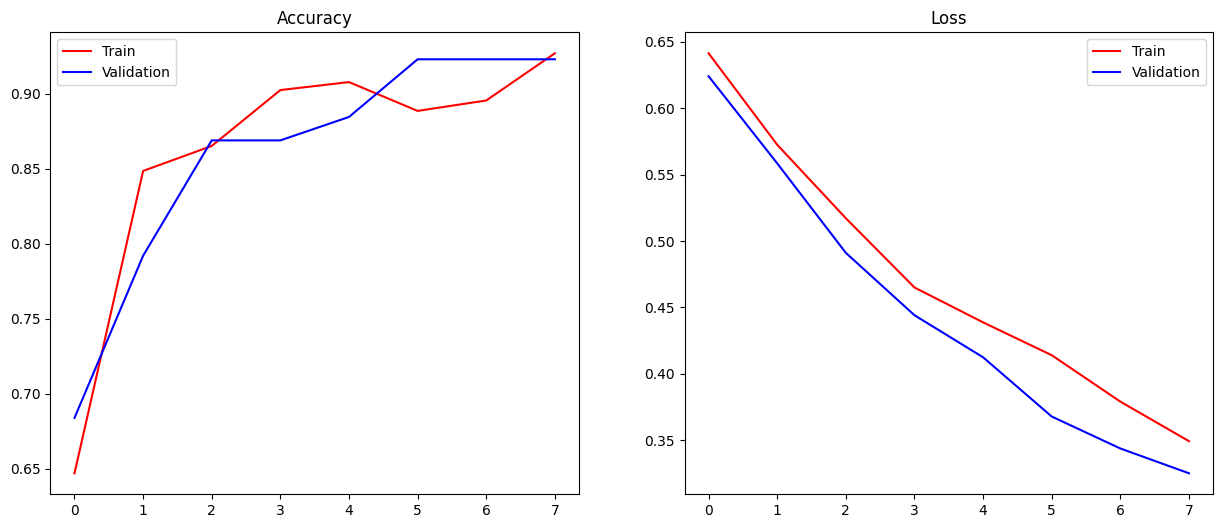

In [8]:
import matplotlib.pyplot as plt
def plot_summary(train_loss_list, val_loss_list,train_acc_list,  val_acc_list, epochs_list):
  my_list = [train_acc_list, val_acc_list, train_loss_list, val_loss_list]
  fig, axes = plt.subplots(1, 2, figsize = (15, 6))
  for i in range(2):
    axes[i].plot(epochs_list, my_list[i*2], c= 'red', label = 'Train')
    axes[i].plot(epochs_list, my_list[i*2+1], c = 'blue', label = 'Validation')
    if i == 0:
      axes[i].set_title('Accuracy')
    else: axes[i].set_title('Loss')
    axes[i].legend()
    i+=1


plot_summary(train_loss_list, val_loss_list,train_acc_list,  val_acc_list, epochs_list)
